In [1]:
#import libreries
import kagglehub
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

from datetime import datetime

In [92]:
#load dataset from kaggel
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nehalbirla/vehicle-dataset-from-cardekho")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'vehicle-dataset-from-cardekho' dataset.
Path to dataset files: /kaggle/input/vehicle-dataset-from-cardekho


In [93]:
data = pd.read_csv(os.path.join(path, files[0]))

data.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


In [94]:
#datatypes
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   object 
 1   Model               2059 non-null   object 
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   object 
 6   Transmission        2059 non-null   object 
 7   Location            2059 non-null   object 
 8   Color               2059 non-null   object 
 9   Owner               2059 non-null   object 
 10  Seller Type         2059 non-null   object 
 11  Engine              1979 non-null   object 
 12  Max Power           1979 non-null   object 
 13  Max Torque          1979 non-null   object 
 14  Drivetrain          1923 non-null   object 
 15  Length              1995 non-null   float64
 16  Width 

In [95]:
#missing values
data.describe()

,Price,Year,Kilometer,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
count,2.059000e+03,2059.000000,2.059000e+03,1995.000000,1995.000000,1995.000000,1995.000000,1946.000000
mean,1.702992e+06,2016.425449,5.422471e+04,4280.860652,1767.991980,1591.735338,5.306266,52.002210
std,2.419881e+06,3.363564,5.736172e+04,442.458507,135.265825,136.073956,0.822170,15.110198
min,4.900000e+04,1988.000000,0.000000e+00,3099.000000,1475.000000,1165.000000,2.000000,15.000000
25%,4.849990e+05,2014.000000,2.900000e+04,3985.000000,1695.000000,1485.000000,5.000000,41.250000
50%,8.250000e+05,2017.000000,5.000000e+04,4370.000000,1770.000000,1545.000000,5.000000,50.000000
75%,1.925000e+06,2019.000000,7.200000e+04,4629.000000,1831.500000,1675.000000,5.000000,60.000000
max,3.500000e+07,2022.000000,2.000000e+06,5569.000000,2220.000000,1995.000000,8.000000,105.000000


In [96]:
# Define Features and Target
print('Missing values before imputation:')
display(data.isnull().sum()[data.isnull().sum() > 0])

# Impute numerical columns with median
for col in ['Length', 'Width', 'Height', 'Seating Capacity', 'Fuel Tank Capacity']:
    if col in data.columns:
        data[col] = data[col].fillna(data[col].median())

# Impute categorical columns with mode
for col in ['Engine', 'Max Power', 'Max Torque', 'Drivetrain']:
    if col in data.columns:
        data[col] = data[col].fillna(data[col].mode()[0])

print('\nMissing values after imputation:')
display(data.isnull().sum()[data.isnull().sum() > 0])

Missing values before imputation:


,0
Engine,80
Max Power,80
Max Torque,80
Drivetrain,136
Length,64
Width,64
Height,64
Seating Capacity,64
Fuel Tank Capacity,113



Missing values after imputation:


,0


In [97]:
# Feature Engineering
categorical_cols = data.select_dtypes(include='object').columns

encoder = LabelEncoder()
for col in categorical_cols:
    data[col] = encoder.fit_transform(data[col])

print('Data types after encoding:')
display(data.info())

Data types after encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   int64  
 1   Model               2059 non-null   int64  
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   int64  
 6   Transmission        2059 non-null   int64  
 7   Location            2059 non-null   int64  
 8   Color               2059 non-null   int64  
 9   Owner               2059 non-null   int64  
 10  Seller Type         2059 non-null   int64  
 11  Engine              2059 non-null   int64  
 12  Max Power           2059 non-null   int64  
 13  Max Torque          2059 non-null   int64  
 14  Drivetrain          2059 non-null   int64  
 15  Length              2059 non

None

In [99]:
X = data.drop("Price", axis=1)
y = data["Price"]

In [100]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [101]:
print('Fitting RandomForestRegressor...')
rf_model.fit(X_train, y_train)
print('RandomForestRegressor fitted.')

print('Fitting GradientBoostingRegressor...')
gb_model.fit(X_train, y_train)
print('GradientBoostingRegressor fitted.')

print('Fitting XGBRegressor...')
xgb_model.fit(X_train, y_train)
print('XGBRegressor fitted.')

Fitting RandomForestRegressor...
RandomForestRegressor fitted.
Fitting GradientBoostingRegressor...
GradientBoostingRegressor fitted.
Fitting XGBRegressor...
XGBRegressor fitted.


In [113]:
# data.drop("Year", axis=1, inplace=True)

In [102]:
# Encode Categorical Variables
encoder = LabelEncoder()

data["Fuel Type"] = encoder.fit_transform(data["Fuel Type"])
data["Transmission"] = encoder.fit_transform(data["Transmission"])
data["Owner"] = encoder.fit_transform(data["Owner"])

In [104]:
# Split Dataset (Train/Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [105]:
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)

In [106]:
gb_model = GradientBoostingRegressor()

In [107]:
xgb_model = XGBRegressor(objective='reg:squarederror')

In [108]:
# Train Models
rf_model.fit(X_train, y_train)

gb_model.fit(X_train, y_train)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [109]:
#Make Predictions
#Random Forest
rf_pred = rf_model.predict(X_test)
#Gradient Boosting
gb_pred = gb_model.predict(X_test)
#XGBoost
xgb_pred = xgb_model.predict(X_test)
evaluate_model("Random Forest",y_test,rf_pred)
evaluate_model("Gradient Boosting",y_test,gb_pred)
evaluate_model("XGBoost",y_test,xgb_pred)

Random Forest
RMSE: 1224672.4727923793
R2 Score: 0.7853189114028922
Gradient Boosting
RMSE: 1063932.6594861185
R2 Score: 0.837974952446439
XGBoost
RMSE: 1105086.263507062
R2 Score: 0.8251980543136597


In [110]:
#Model Evaluation
def evaluate_model(name, y_test, pred):

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    print(name)
    print("RMSE:", rmse)
    print("R2 Score:", r2)

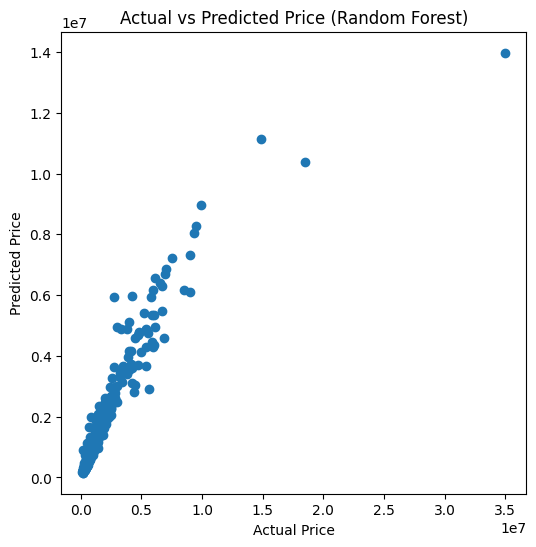

In [115]:
#Actual vs Predicted Price
plt.figure(figsize=(6,6))

plt.scatter(y_test,rf_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Price (Random Forest)")

plt.show()

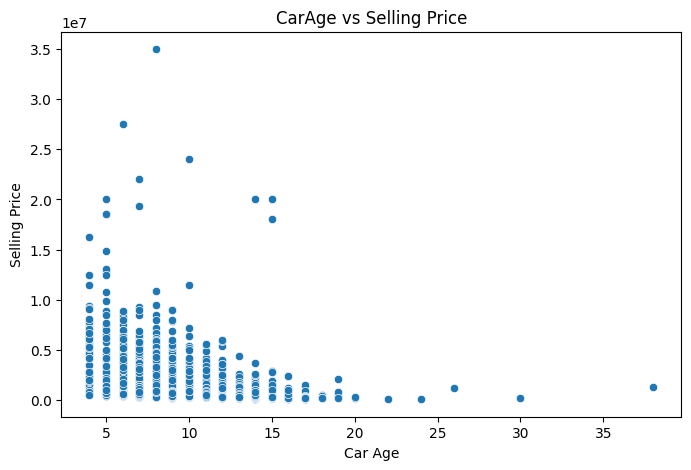

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create CarAge feature if it doesn't exist
if "CarAge" not in data.columns:
    current_year = datetime.now().year
    data["CarAge"] = current_year - data["Year"]

plt.figure(figsize=(8,5))

sns.scatterplot(x=data["CarAge"],y=data["Price"])

plt.title("CarAge vs Selling Price")

plt.xlabel("Car Age")

plt.ylabel("Selling Price")

plt.show()

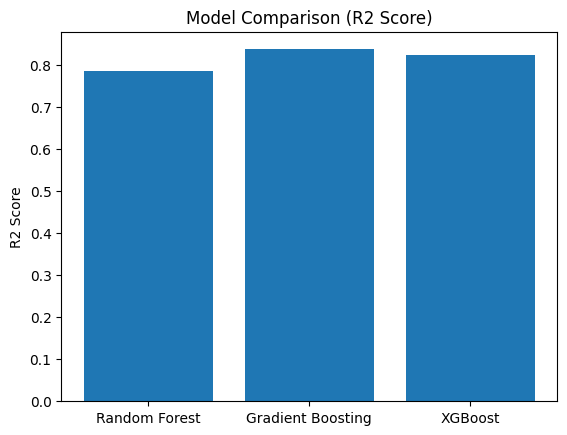

In [117]:
#Model Comparison

models = ["Random Forest","Gradient Boosting","XGBoost"]

scores = [
r2_score(y_test,rf_pred),
r2_score(y_test,gb_pred),
r2_score(y_test,xgb_pred)
]

plt.bar(models,scores)

plt.title("Model Comparison (R2 Score)")

plt.ylabel("R2 Score")

plt.show()

In [126]:
##   deployment

import kagglehub
import os
import pandas as pd
import numpy as np

from sklearn.ensemble import GradientBoostingRegressor

# Download dataset
path = kagglehub.dataset_download("nehalbirla/vehicle-dataset-from-cardekho")

file_path = os.path.join(path, "car data.csv")
data = pd.read_csv(file_path)

# Feature engineering
current_year = 2024
data["CarAge"] = current_year - data["Year"]

# Encode categorical features
data["Fuel_Type"] = data["Fuel_Type"].astype("category").cat.codes
data["Transmission"] = data["Transmission"].astype("category").cat.codes

# Select features
X = data[["CarAge", "Fuel_Type", "Transmission", "Owner", "Kms_Driven"]]
y = data["Selling_Price"]

# Train model
gb_model = GradientBoostingRegressor()
gb_model.fit(X, y)

print("Model trained successfully")

Using Colab cache for faster access to the 'vehicle-dataset-from-cardekho' dataset.
Model trained successfully


In [ ]:
import gradio as gr
import pandas as pd
import numpy as np

def predict_price(car_age, fuel, transmission, owner, km_driven):

    # Convert inputs to integers
    car_age = int(car_age)
    fuel = int(fuel)
    transmission = int(transmission)
    owner = int(owner)
    km_driven = int(km_driven)

    # Create dataframe with same columns used in training
    input_data = pd.DataFrame(
        [[car_age, fuel, transmission, owner, km_driven]],
        columns=["CarAge","fuel","transmission","owner","km_driven"]
    )

    prediction = gb_model.predict(input_data)[0]

    return f"Predicted Car Price: ₹{int(prediction)}"


interface = gr.Interface(
    fn=predict_price,
    inputs=[
        gr.Number(label="Car Age"),
        gr.Number(label="Fuel Type (0=Petrol,1=Diesel,2=CNG)"),
        gr.Number(label="Transmission (0=Manual,1=Automatic)"),
        gr.Number(label="Owner"),
        gr.Number(label="Kilometers Driven")
    ],
    outputs="text",
    title="🚗 Car Price Prediction"
)

interface.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://93e308a1214ecaf6cb.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/gradio/queueing.py", line 759, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/route_utils.py", line 354, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 2191, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 1698, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/anyio/to_thread.py", line 63, in run_sync
    return await get_async_backend().run_sync_in_worker_thread(
           ^^^^^

Created dataset file at: .gradio/flagged/dataset1.csv
